In [ ]:
import sys
sys.path.insert(0, '..')

# =====================================================
# EXPLORATORY ANALYSIS: METRICS OVER TIME
# =====================================================
# This notebook analyzes how metrics changes over time
# for different player types, with 95% confidence intervals.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Import utility functions from plot_utilities
from plot_utilities import (
    load_turn_data,
    setup_notebook_display,
    plot_metric_over_time  # Generalized function for any metric
)

# Set up notebook display and plotting style
setup_notebook_display(figsize=(12, 6))

# Load turn data with player type mapping automatically applied
turn_df = load_turn_data('../turn_data.csv', condition_exclude=["observe-vanilla-standard"])

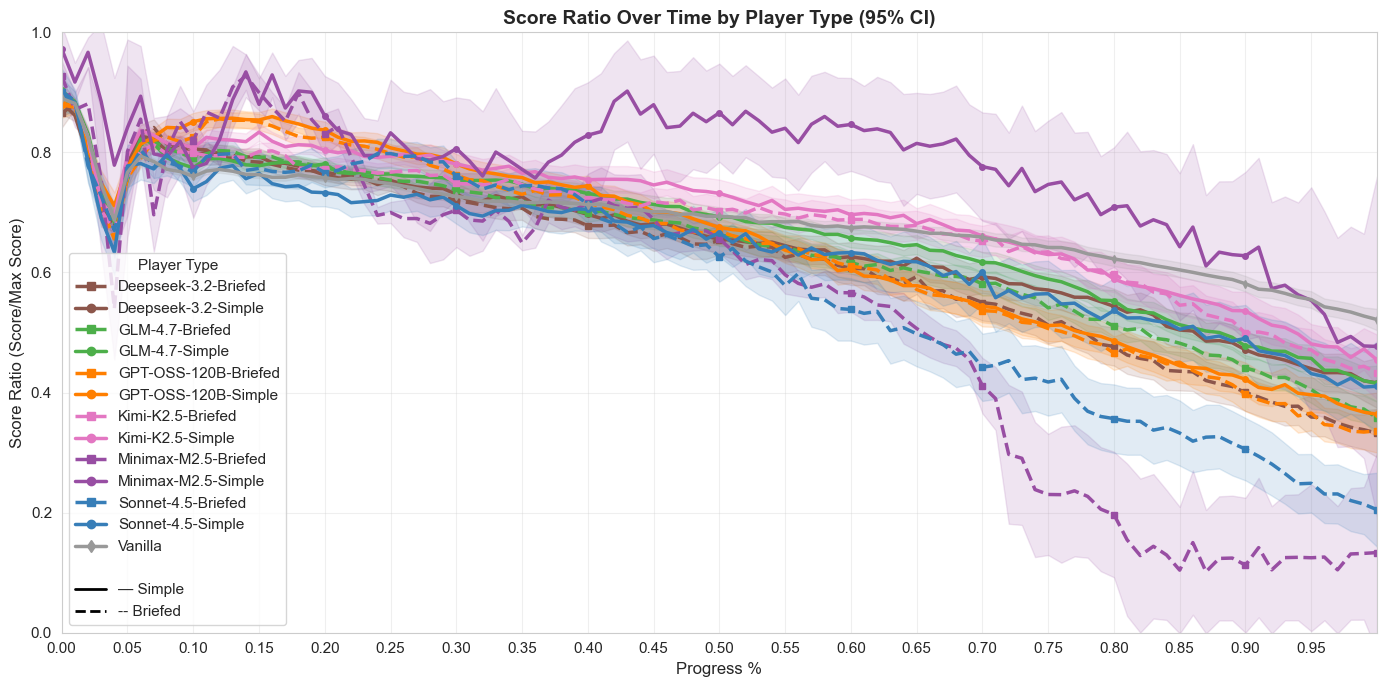

,N,Mean,Std,Min,Max,Slope,r
Deepseek-3.2-Briefed,37407,0.622,0.281,0.000,1.0,-0.478371,-0.493
Deepseek-3.2-Simple,37407,0.650,0.260,0.000,1.0,-0.385749,-0.430
GLM-4.7-Briefed,69471,0.641,0.261,0.000,1.0,-0.432922,-0.480
GLM-4.7-Simple,69471,0.667,0.239,0.000,1.0,-0.377707,-0.458
GPT-OSS-120B-Briefed,40077,0.636,0.275,0.000,1.0,-0.526170,-0.551
GPT-OSS-120B-Simple,40077,0.649,0.271,0.000,1.0,-0.524668,-0.560
Kimi-K2.5-Briefed,38515,0.682,0.260,0.000,1.0,-0.334760,-0.373
Kimi-K2.5-Simple,38515,0.701,0.263,0.000,1.0,-0.348599,-0.383
Minimax-M2.5-Briefed,1108,0.538,0.289,0.000,1.0,-0.867789,-0.861
Minimax-M2.5-Simple,1108,0.779,0.194,0.152,1.0,-0.280575,-0.414


In [2]:
# Plot score ratio over time using the generalized plot_metric_over_time function
# This calculates score_ratio as score/max_score dynamically
fig, ax = plot_metric_over_time(
    turn_df,
    metric_calculation=lambda df: df['score'] / df['max_score'],
    title="Score Ratio Over Time by Player Type",
    ylabel="Score Ratio (Score/Max Score)",
    figsize=(14, 7),
    show_confidence=True,
    confidence_level=0.95,
    print_summary=True,
    use_turn_progress=True,
    ylim=(0, 1)  # Score ratio is always between 0 and 1
)

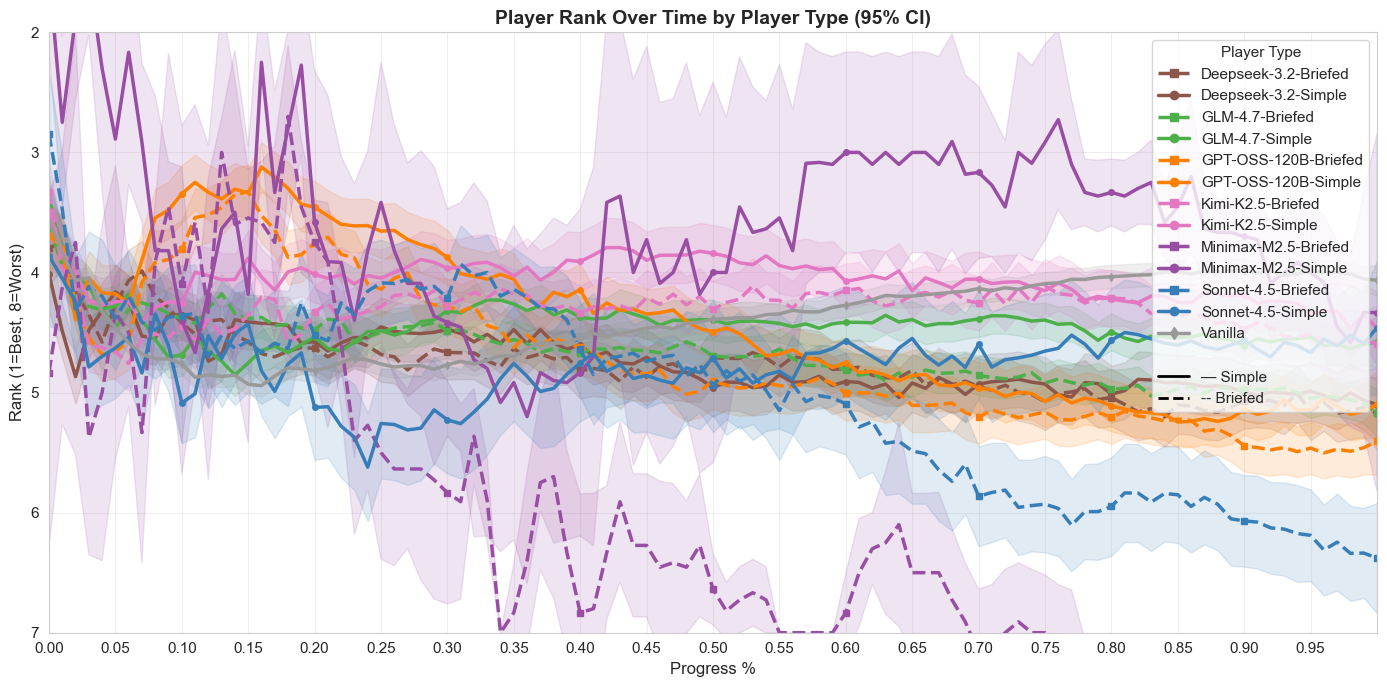

,N,Mean,Std,Min,Max,Slope,r
Deepseek-3.2-Briefed,37407,4.777,2.318,1,8,0.880103,0.110
Deepseek-3.2-Simple,37407,4.752,2.333,1,8,0.723099,0.090
GLM-4.7-Briefed,69471,4.677,2.234,1,8,0.872041,0.113
GLM-4.7-Simple,69471,4.447,2.211,1,8,0.148050,0.019
GPT-OSS-120B-Briefed,40077,4.715,2.367,1,8,1.858168,0.227
GPT-OSS-120B-Simple,40077,4.430,2.306,1,8,2.017355,0.252
Kimi-K2.5-Briefed,38515,4.307,2.304,1,8,0.014293,0.002
Kimi-K2.5-Simple,38515,4.065,2.340,1,8,0.235071,0.029
Minimax-M2.5-Briefed,1108,6.181,1.707,1,8,4.179739,0.702
Minimax-M2.5-Simple,1108,3.638,1.778,1,8,0.107511,0.017


In [3]:
# Create the rank over time plot with 95% confidence intervals
# Using the generalized plot_metric_over_time function
# Note: Lower rank is better (1 = first place, 4 = last place)
# We invert the y-axis to show better performance at the top
fig, ax = plot_metric_over_time(
    turn_df,
    metric_col='rank',  # Use the 'rank' column directly
    title="Player Rank Over Time by Player Type",
    ylabel="Rank (1=Best, 8=Worst)",
    figsize=(14, 7),
    show_confidence=True,
    confidence_level=0.95,
    print_summary=True,
    use_turn_progress=True,
    ylim=(2, 7),   # Set y-axis limits for rank (1-8 with padding)
    invert_y=True,     # Invert y-axis so lower (better) rank appears higher
    legend_loc='upper right'
)

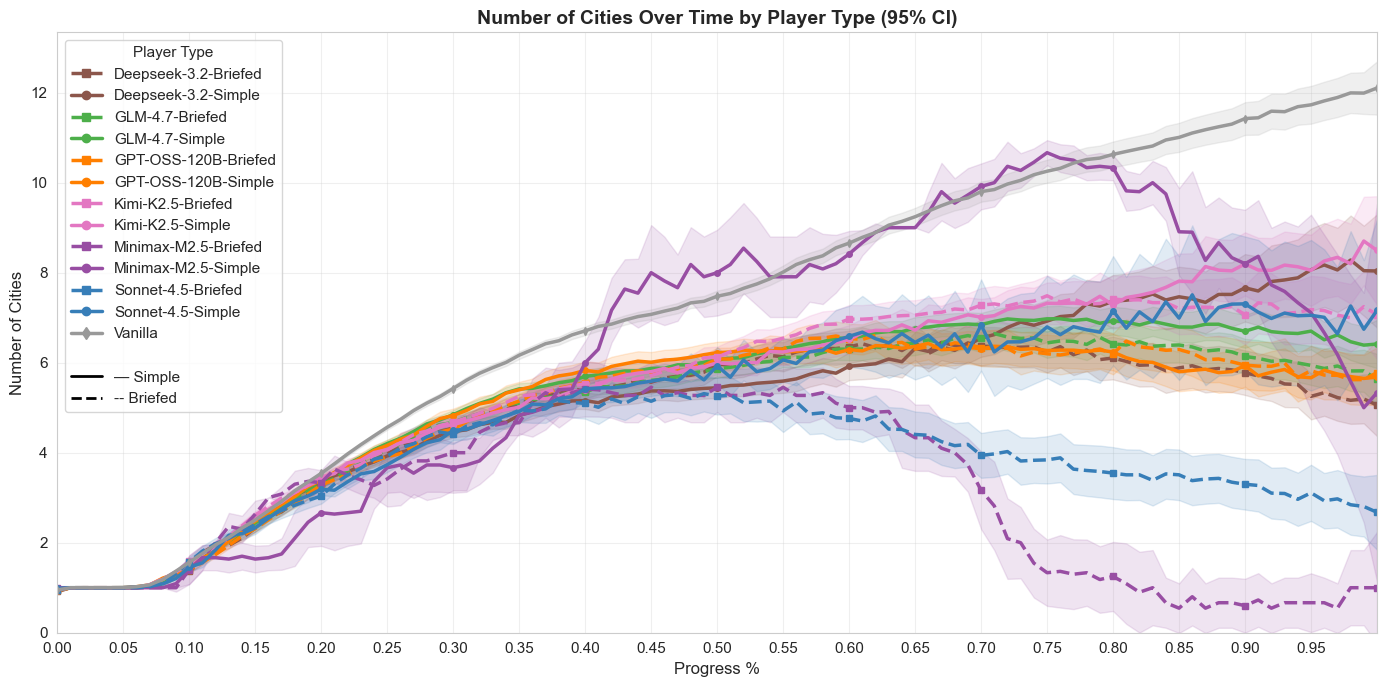

,N,Mean,Std,Min,Max,Slope,r
Deepseek-3.2-Briefed,37407,4.809,3.684,0,25,4.833590,0.380
Deepseek-3.2-Simple,37407,5.182,4.644,0,49,7.057121,0.440
GLM-4.7-Briefed,69471,4.954,3.798,0,41,5.346798,0.407
GLM-4.7-Simple,69471,5.241,3.606,0,31,5.971965,0.479
GPT-OSS-120B-Briefed,40077,4.947,3.787,0,24,5.162878,0.393
GPT-OSS-120B-Simple,40077,4.984,3.521,0,26,4.810394,0.394
Kimi-K2.5-Briefed,38515,5.406,4.232,0,39,6.691179,0.457
Kimi-K2.5-Simple,38515,5.478,4.576,0,58,7.446577,0.471
Minimax-M2.5-Briefed,1108,3.046,2.060,0,7,-1.742779,-0.243
Minimax-M2.5-Simple,1108,6.255,3.455,1,12,9.121890,0.757


In [4]:
# Plot number of cities over time using the generalized plot_metric_over_time function
# Cities are a key indicator of expansion and empire building in Civilization
fig, ax = plot_metric_over_time(
    turn_df,
    metric_col='cities',  # Use the 'cities' column directly
    title="Number of Cities Over Time by Player Type",
    ylabel="Number of Cities",
    figsize=(14, 7),
    show_confidence=True,
    confidence_level=0.95,
    use_turn_progress=True,
    print_summary=True,
    ylim=(0, None),    # Start at 0, let max adjust automatically
    legend_loc='upper left'  # Cities generally increase over time
)

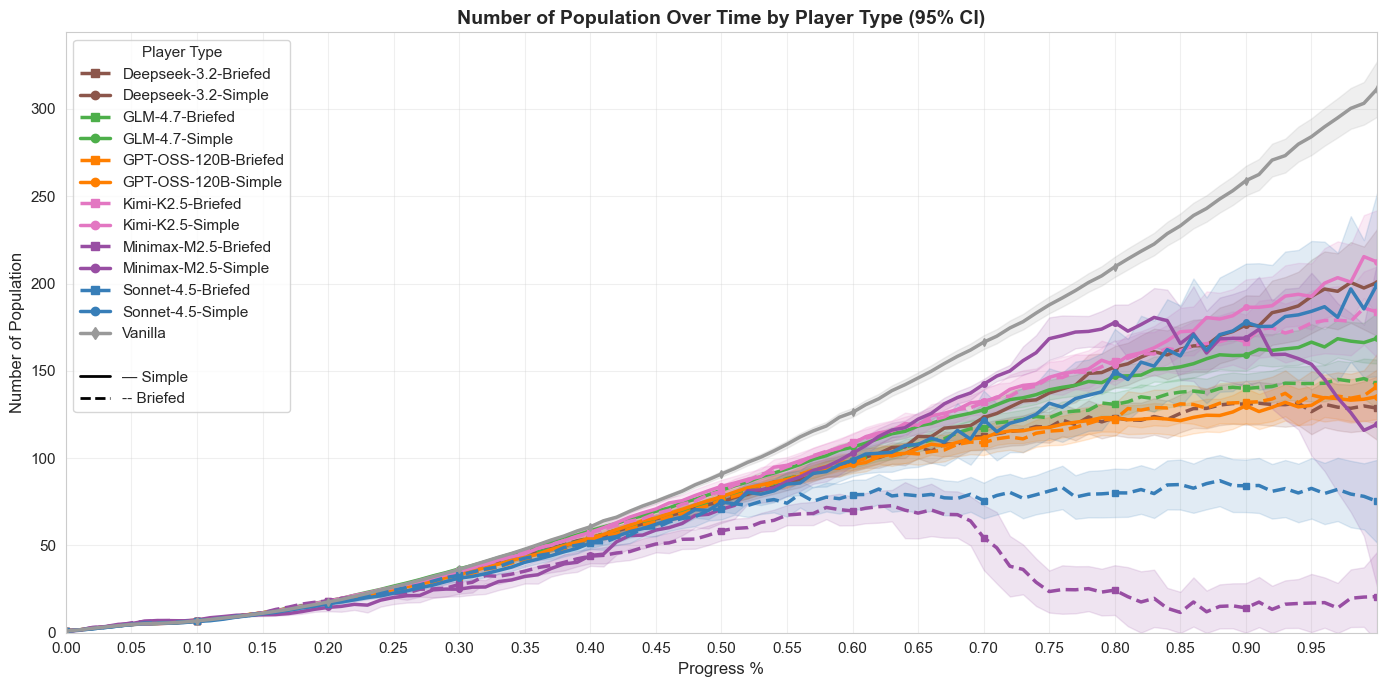

,N,Mean,Std,Min,Max,Slope,r
Deepseek-3.2-Briefed,37407,71.816,80.076,0,651,157.035798,0.568
Deepseek-3.2-Simple,37407,83.828,107.873,0,1122,212.733091,0.571
GLM-4.7-Briefed,69471,75.362,81.903,0,965,171.173109,0.604
GLM-4.7-Simple,69471,83.022,85.829,0,785,194.843883,0.656
GPT-OSS-120B-Briefed,40077,72.346,81.996,0,764,160.982280,0.567
GPT-OSS-120B-Simple,40077,72.286,74.079,0,603,157.050635,0.612
Kimi-K2.5-Briefed,38515,85.575,102.024,0,898,208.551093,0.591
Kimi-K2.5-Simple,38515,88.989,107.922,0,1322,223.707224,0.600
Minimax-M2.5-Briefed,1108,32.740,26.768,0,103,16.647269,0.178
Minimax-M2.5-Simple,1108,82.610,68.659,1,264,206.665094,0.863


In [5]:
# Plot number of population over time using the generalized plot_metric_over_time function
# Cities are a key indicator of expansion and empire building in Civilization
fig, ax = plot_metric_over_time(
    turn_df,
    metric_col='population',  # Use the 'population' column directly
    title="Number of Population Over Time by Player Type",
    ylabel="Number of Population",
    figsize=(14, 7),
    show_confidence=True,
    confidence_level=0.95,
    use_turn_progress=True,
    print_summary=True,
    ylim=(0, None),    # Start at 0, let max adjust automatically
    legend_loc='upper left'  # Population generally increase over time
)

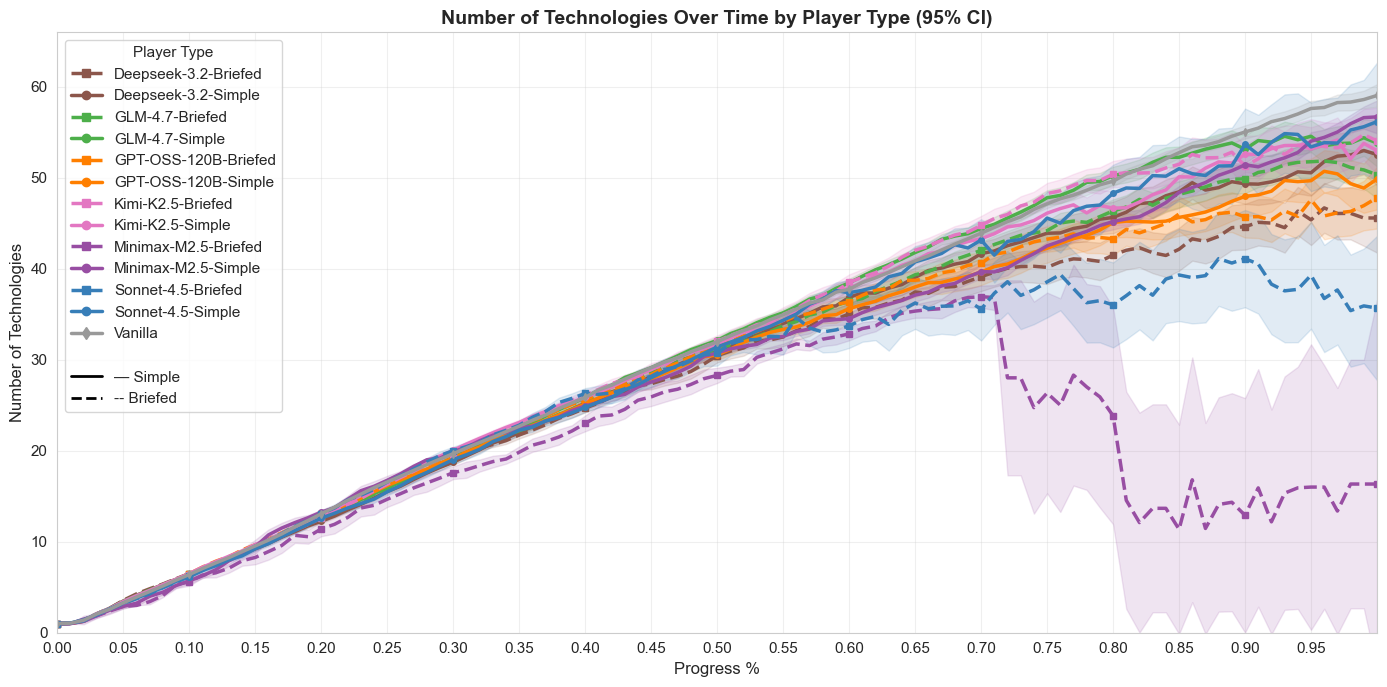

,N,Mean,Std,Min,Max,Slope,r
Deepseek-3.2-Briefed,37407,27.644,19.680,0,82,47.512353,0.699
Deepseek-3.2-Simple,37407,29.395,19.661,0,82,54.386262,0.801
GLM-4.7-Briefed,69471,29.669,19.832,0,82,54.383230,0.793
GLM-4.7-Simple,69471,31.184,20.072,0,82,59.019310,0.850
GPT-OSS-120B-Briefed,40077,28.937,19.010,0,82,49.537602,0.752
GPT-OSS-120B-Simple,40077,28.953,19.382,0,82,51.486983,0.767
Kimi-K2.5-Briefed,38515,31.030,20.662,0,82,58.378178,0.817
Kimi-K2.5-Simple,38515,30.549,20.115,0,82,56.356731,0.811
Minimax-M2.5-Briefed,1108,19.675,14.712,0,49,15.667697,0.305
Minimax-M2.5-Simple,1108,29.639,15.742,1,59,54.704167,0.996


In [6]:
# Plot number of technologies over time using the generalized plot_metric_over_time function
fig, ax = plot_metric_over_time(
    turn_df,
    metric_col='technologies',  # Use the 'technologies' column directly
    title="Number of Technologies Over Time by Player Type",
    ylabel="Number of Technologies",
    figsize=(14, 7),
    show_confidence=True,
    confidence_level=0.95,
    print_summary=True,
    use_turn_progress=True,
    ylim=(0, None),    # Start at 0, let max adjust automatically
    legend_loc='upper left'  # Technology generally increase over time
)

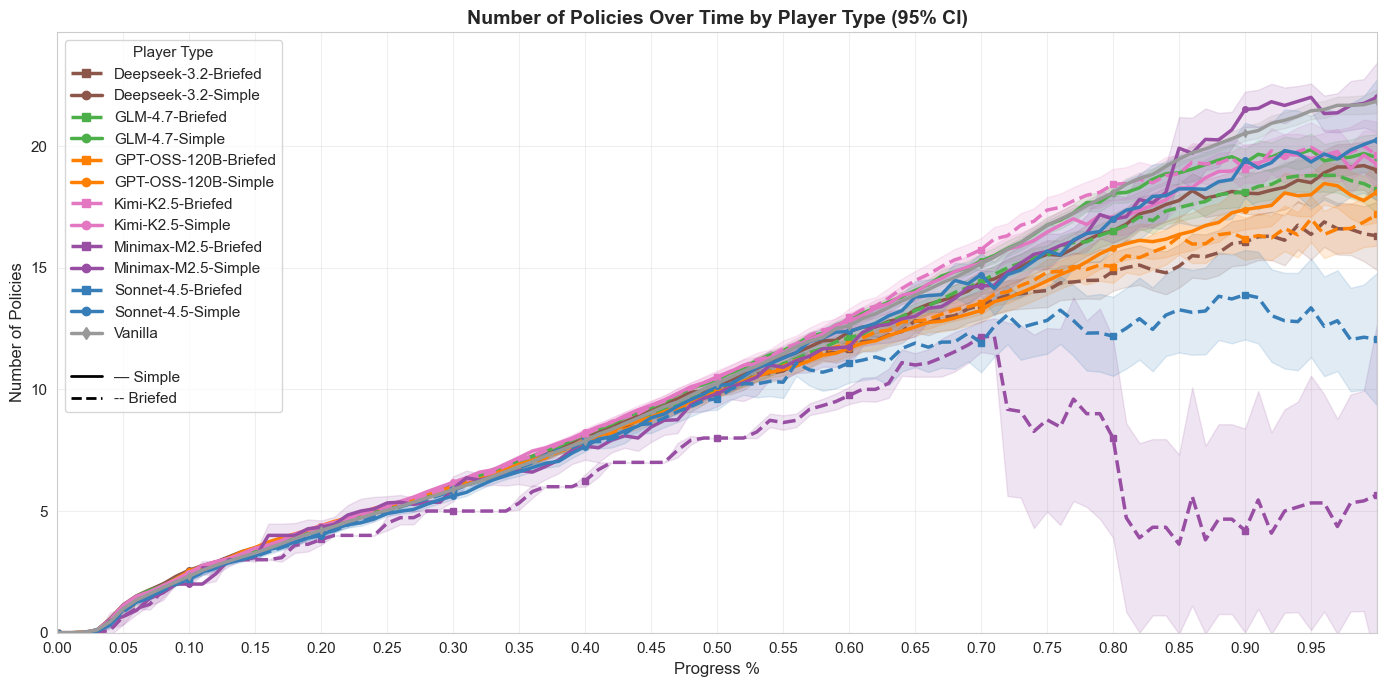

,N,Mean,Std,Min,Max,Slope,r
Deepseek-3.2-Briefed,37407,9.470,7.203,0,33,17.295553,0.695
Deepseek-3.2-Simple,37407,10.216,7.318,0,34,19.943610,0.789
GLM-4.7-Briefed,69471,10.141,7.334,0,33,19.972729,0.788
GLM-4.7-Simple,69471,10.699,7.439,0,35,21.606928,0.840
GPT-OSS-120B-Briefed,40077,9.652,6.945,0,38,17.860267,0.742
GPT-OSS-120B-Simple,40077,9.841,7.042,0,35,18.687525,0.766
Kimi-K2.5-Briefed,38515,10.769,7.950,0,36,21.902074,0.797
Kimi-K2.5-Simple,38515,10.590,7.583,0,34,21.011627,0.802
Minimax-M2.5-Briefed,1108,6.019,4.690,0,17,5.369246,0.328
Minimax-M2.5-Simple,1108,10.615,6.602,0,24,22.580891,0.980


In [7]:
# Plot number of policies over time using the generalized plot_metric_over_time function
fig, ax = plot_metric_over_time(
    turn_df,
    metric_col='policies',  # Use the 'policies' column directly
    title="Number of Policies Over Time by Player Type",
    ylabel="Number of Policies",
    figsize=(14, 7),
    show_confidence=True,
    confidence_level=0.95,
    print_summary=True,
    use_turn_progress=True,
    ylim=(0, None),    # Start at 0, let max adjust automatically
    legend_loc='upper left'  # Technology generally increase over time
)